In [2]:
import pandas as pd
import numpy as np

In [3]:

for f in ["studentInfo.csv", "studentRegistration.csv", "assessments.csv",
          "studentAssessment.csv", "vle.csv", "studentVle.csv", "courses.csv"]:
    df=pd.read_csv(f,nrows=2)
    print(f"\n{f}: {list(df.columns)}")


studentInfo.csv: ['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result']

studentRegistration.csv: ['code_module', 'code_presentation', 'id_student', 'date_registration', 'date_unregistration']

assessments.csv: ['code_module', 'code_presentation', 'id_assessment', 'assessment_type', 'date', 'weight']

studentAssessment.csv: ['id_assessment', 'id_student', 'date_submitted', 'is_banked', 'score']

vle.csv: ['id_site', 'code_module', 'code_presentation', 'activity_type', 'week_from', 'week_to']

studentVle.csv: ['code_module', 'code_presentation', 'id_student', 'id_site', 'date', 'sum_click']

courses.csv: ['code_module', 'code_presentation', 'module_presentation_length']


In [52]:
vle_early=pd.read_csv("studentVle.csv",usecols=['code_module', 'code_presentation', 'id_student', 'id_site', 'date', 'sum_click']
              ,dtype={"id_student":"int32","date":"int16","sum_click":"int32","id_site":"int32"}
                     )
vle_early=vle_early[vle_early["date"]<=14]

In [53]:
vle_early.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1819777 entries, 0 to 10558245
Data columns (total 6 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   code_module        object
 1   code_presentation  object
 2   id_student         int32 
 3   id_site            int32 
 4   date               int16 
 5   sum_click          int32 
dtypes: int16(1), int32(3), object(2)
memory usage: 65.9+ MB


In [6]:
ID_KEYS = ["id_student", "code_module", "code_presentation"]

In [7]:

vle_features=vle_early.groupby(ID_KEYS).agg(
    total_click=("sum_click","sum"),
    active_days=("date","nunique"),
    last_login_day=("date","max"),
    avg_click_per_day=("sum_click","mean")
    
).reset_index()

In [8]:
vle_features.head()

,id_student,code_module,code_presentation,total_click,active_days,last_login_day,avg_click_per_day
0,6516,AAA,2014J,548,20,14,4.892857
1,8462,DDD,2013J,314,15,14,2.803571
2,8462,DDD,2014J,10,1,10,2.500000
3,11391,AAA,2013J,301,6,9,6.688889
4,23629,BBB,2013B,42,4,9,2.470588


In [9]:
vle_features["days_since_last_login"]=14-vle_features["last_login_day"]

In [10]:
vle_features.head(
    
)

,id_student,code_module,code_presentation,total_click,active_days,last_login_day,avg_click_per_day,days_since_last_login
0,6516,AAA,2014J,548,20,14,4.892857,0
1,8462,DDD,2013J,314,15,14,2.803571,0
2,8462,DDD,2014J,10,1,10,2.500000,4
3,11391,AAA,2013J,301,6,9,6.688889,5
4,23629,BBB,2013B,42,4,9,2.470588,5


In [11]:
vle_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28081 entries, 0 to 28080
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_student             28081 non-null  int32  
 1   code_module            28081 non-null  object 
 2   code_presentation      28081 non-null  object 
 3   total_click            28081 non-null  int32  
 4   active_days            28081 non-null  int64  
 5   last_login_day         28081 non-null  int16  
 6   avg_click_per_day      28081 non-null  float64
 7   days_since_last_login  28081 non-null  int16  
dtypes: float64(1), int16(2), int32(2), int64(1), object(2)
memory usage: 1.2+ MB


# ^|COMPLETED STUDENTVLE.CSV FROM STUDENTS ACTIVITY/CLICK BEHAVIOUR

In [12]:
df=pd.read_csv("studentInfo.csv")

In [13]:
df

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass
...,...,...,...,...,...,...,...,...,...,...,...,...
32588,GGG,2014J,2640965,F,Wales,Lower Than A Level,10-20,0-35,0,30,N,Fail
32589,GGG,2014J,2645731,F,East Anglian Region,Lower Than A Level,40-50%,35-55,0,30,N,Distinction
32590,GGG,2014J,2648187,F,South Region,A Level or Equivalent,20-30%,0-35,0,30,Y,Pass
32591,GGG,2014J,2679821,F,South East Region,Lower Than A Level,90-100%,35-55,0,30,N,Withdrawn


In [14]:
df["id_student"]=df["id_student"].astype("int32")

In [15]:
vle_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28081 entries, 0 to 28080
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_student             28081 non-null  int32  
 1   code_module            28081 non-null  object 
 2   code_presentation      28081 non-null  object 
 3   total_click            28081 non-null  int32  
 4   active_days            28081 non-null  int64  
 5   last_login_day         28081 non-null  int16  
 6   avg_click_per_day      28081 non-null  float64
 7   days_since_last_login  28081 non-null  int16  
dtypes: float64(1), int16(2), int32(2), int64(1), object(2)
memory usage: 1.2+ MB


In [16]:
df["id_student"].nunique()

28785

In [17]:
vle_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28081 entries, 0 to 28080
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_student             28081 non-null  int32  
 1   code_module            28081 non-null  object 
 2   code_presentation      28081 non-null  object 
 3   total_click            28081 non-null  int32  
 4   active_days            28081 non-null  int64  
 5   last_login_day         28081 non-null  int16  
 6   avg_click_per_day      28081 non-null  float64
 7   days_since_last_login  28081 non-null  int16  
dtypes: float64(1), int16(2), int32(2), int64(1), object(2)
memory usage: 1.2+ MB


In [18]:
merged=pd.merge(
    vle_features,
    df,
    on=["code_module","id_student","code_presentation"],
    how="inner"
)

In [19]:
activity_cols=[
    "total_click",
    "active_days",
    "last_login_day",
    "avg_click_per_day",
    "days_since_last_login"
]
merged[activity_cols]=merged[activity_cols].fillna(0)

In [20]:
merged.isnull().sum()

id_student                  0
code_module                 0
code_presentation           0
total_click                 0
active_days                 0
last_login_day              0
avg_click_per_day           0
days_since_last_login       0
gender                      0
region                      0
highest_education           0
imd_band                 1037
age_band                    0
num_of_prev_attempts        0
studied_credits             0
disability                  0
final_result                0
dtype: int64

In [21]:
merged["imd_band"]

0         80-90%
1         30-40%
2         30-40%
3        90-100%
4         20-30%
          ...   
28076     50-60%
28077     60-70%
28078     50-60%
28079     50-60%
28080     30-40%
Name: imd_band, Length: 28081, dtype: object

In [22]:
merged.head(14)

,id_student,code_module,code_presentation,total_click,active_days,last_login_day,avg_click_per_day,days_since_last_login,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,6516,AAA,2014J,548,20,14,4.892857,0,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass
1,8462,DDD,2013J,314,15,14,2.803571,0,M,London Region,HE Qualification,30-40%,55<=,0,90,N,Withdrawn
2,8462,DDD,2014J,10,1,10,2.500000,4,M,London Region,HE Qualification,30-40%,55<=,1,60,N,Withdrawn
3,11391,AAA,2013J,301,6,9,6.688889,5,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
4,23629,BBB,2013B,42,4,9,2.470588,5,F,East Anglian Region,Lower Than A Level,20-30%,0-35,2,60,N,Fail
5,23698,CCC,2014J,346,23,13,3.460000,1,F,East Anglian Region,A Level or Equivalent,50-60%,0-35,0,120,N,Pass
6,23798,BBB,2013J,94,6,13,2.238095,1,M,Wales,A Level or Equivalent,50-60%,0-35,0,60,N,Distinction
7,24186,GGG,2014B,14,2,6,1.750000,8,F,Yorkshire Region,Lower Than A Level,10-20,0-35,0,30,Y,Pass
8,24213,DDD,2014B,324,15,13,3.681818,1,F,East Anglian Region,A Level or Equivalent,40-50%,0-35,1,60,N,Pass
9,24391,GGG,2013J,32,4,14,2.133333,0,M,East Midlands Region,A Level or Equivalent,80-90%,0-35,0,30,N,Distinction


In [23]:
merged["avg_click_per_day"]=merged["total_click"]/merged["active_days"].replace(0,np.nan)
merged["avg_click_per_day"]=merged["avg_click_per_day"].fillna(0)

In [24]:
merged["imd_band"].isnull().sum()

np.int64(1037)

In [25]:
merged["imd_band"] = merged["imd_band"].astype(str).str.strip()

In [26]:
merged["imd_band"]=merged["imd_band"].fillna("unknown")
mapping = {
    "0-10%": 1,
    "10-20%": 2,
    "20-30%": 3,
    "30-40%": 4,
    "40-50%": 5,
    "50-60%": 6,
    "60-70%": 7,
    "70-80%": 8,
    "80-90%": 9,
    "90-100%": 10,
      "0-10": 1,
    "10-20": 2,
    "20-30": 3,
    "30-40": 4,
    "40-50": 5,
    "50-60": 6,
    "60-70": 7,
    "70-80": 8,
    "80-90": 9,
    "90-100": 10,
    "Unknown": 0
}

merged["imd_band"]=merged["imd_band"].map(mapping)

In [27]:
# merged["imd_band"]=merged["imd_band"].map(mapping)

In [29]:
# merged.head(14)

In [30]:
# merged.to_csv("studentsvleinfo.csv")

In [44]:
df1=pd.read_csv("result2.csv")
df1

,Unnamed: 0,id_student,code_module,code_presentation,total_click,active_days,last_login_day,avg_click_per_day,days_since_last_login,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,0,6516,AAA,2014J,548,20,14,27.400000,0,M,Scotland,HE Qualification,9.0,55<=,0,60,N,Pass
1,1,8462,DDD,2013J,314,15,14,20.933333,0,M,London Region,HE Qualification,4.0,55<=,0,90,N,Withdrawn
2,2,8462,DDD,2014J,10,1,10,10.000000,4,M,London Region,HE Qualification,4.0,55<=,1,60,N,Withdrawn
3,3,11391,AAA,2013J,301,6,9,50.166667,5,M,East Anglian Region,HE Qualification,10.0,55<=,0,240,N,Pass
4,4,23629,BBB,2013B,42,4,9,10.500000,5,F,East Anglian Region,Lower Than A Level,3.0,0-35,2,60,N,Fail
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28076,28076,2698251,DDD,2014B,338,15,14,22.533333,0,F,South West Region,A Level or Equivalent,6.0,0-35,0,60,N,Fail
28077,28077,2698257,AAA,2013J,92,6,11,15.333333,3,M,East Midlands Region,Lower Than A Level,7.0,0-35,0,120,N,Pass
28078,28078,2698535,CCC,2014B,395,16,13,24.687500,1,M,Wales,Lower Than A Level,6.0,0-35,0,60,N,Withdrawn
28079,28079,2698535,EEE,2013J,41,7,9,5.857143,5,M,Wales,Lower Than A Level,6.0,0-35,0,60,N,Pass


In [26]:
df=pd.read_csv("studentRegistration.csv")

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   code_module          32593 non-null  object 
 1   code_presentation    32593 non-null  object 
 2   id_student           32593 non-null  int64  
 3   date_registration    32548 non-null  float64
 4   date_unregistration  10072 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 1.2+ MB


In [36]:
df["active_duration"]=df["active_duration"].fillna(0)

In [37]:
df

,code_module,code_presentation,id_student,date_registration,date_unregistration,late_registration,active_duration,withdrew
0,AAA,2013J,11391,-159.0,NaN,0,0.0,0
1,AAA,2013J,28400,-53.0,NaN,0,0.0,0
2,AAA,2013J,30268,-92.0,12.0,0,104.0,1
3,AAA,2013J,31604,-52.0,NaN,0,0.0,0
4,AAA,2013J,32885,-176.0,NaN,0,0.0,0
...,...,...,...,...,...,...,...,...
32588,GGG,2014J,2640965,-4.0,NaN,1,0.0,0
32589,GGG,2014J,2645731,-23.0,NaN,1,0.0,0
32590,GGG,2014J,2648187,-129.0,NaN,0,0.0,0
32591,GGG,2014J,2679821,-49.0,101.0,0,150.0,1


In [29]:
# late registration (0 or 1) 0==false 1==true
df['late_registration'] = (
    df['date_registration'] > -30
).astype(int)

In [30]:
# Active Duration
df["active_duration"]=(df["date_unregistration"]-df["date_registration"])

In [31]:
# withdrewal flag
df["withdrew"]=(df["date_unregistration"].notnull().astype(int))

In [39]:
df["withdrew"].value_counts()

withdrew
0    22521
1    10072
Name: count, dtype: int64

<Axes: xlabel='active_duration', ylabel='Count'>

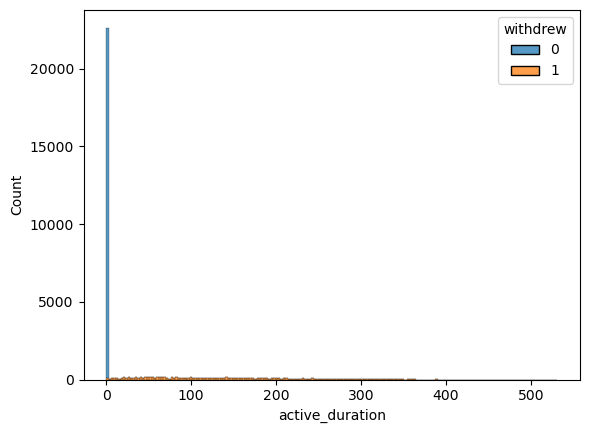

In [38]:
import seaborn as sns
sns.histplot(data=df,x="active_duration",hue="withdrew",multiple="stack")

In [40]:
df.groupby('withdrew')['active_duration'].mean()

withdrew
0      0.000000
1    128.298848
Name: active_duration, dtype: float64

<Axes: xlabel='active_duration', ylabel='Count'>

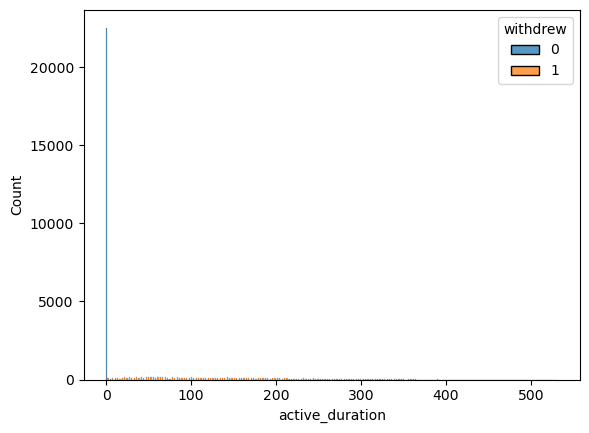

In [41]:
sns.histplot(
    data=df,
    x="active_duration",
    hue="withdrew",
    multiple="dodge"
)

<Axes: xlabel='active_duration', ylabel='Density'>

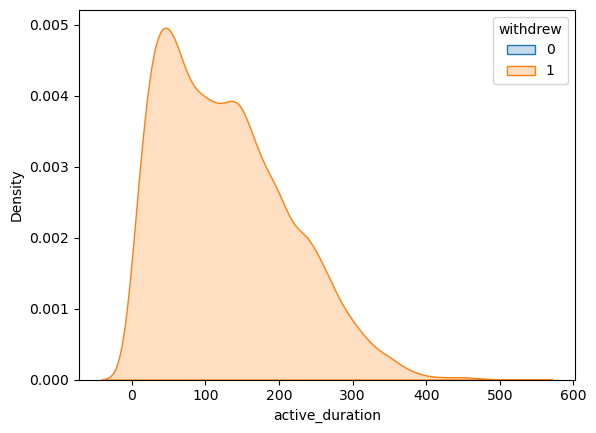

In [13]:
sns.kdeplot(
    data=df,
    x='active_duration',
    hue='withdrew',
    fill=True
)

In [49]:
a=pd.merge(df1,df,on=["id_student","code_module","code_presentation"])

In [50]:
a

,Unnamed: 0,id_student,code_module,code_presentation,total_click,active_days,last_login_day,avg_click_per_day,days_since_last_login,gender,...,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration,late_registration,active_duration,withdrew
0,0,6516,AAA,2014J,548,20,14,27.400000,0,M,...,55<=,0,60,N,Pass,-52.0,NaN,0,0.0,0
1,1,8462,DDD,2013J,314,15,14,20.933333,0,M,...,55<=,0,90,N,Withdrawn,-137.0,119.0,0,256.0,1
2,2,8462,DDD,2014J,10,1,10,10.000000,4,M,...,55<=,1,60,N,Withdrawn,-38.0,18.0,0,56.0,1
3,3,11391,AAA,2013J,301,6,9,50.166667,5,M,...,55<=,0,240,N,Pass,-159.0,NaN,0,0.0,0
4,4,23629,BBB,2013B,42,4,9,10.500000,5,F,...,0-35,2,60,N,Fail,-47.0,NaN,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28076,28076,2698251,DDD,2014B,338,15,14,22.533333,0,F,...,0-35,0,60,N,Fail,-23.0,NaN,1,0.0,0
28077,28077,2698257,AAA,2013J,92,6,11,15.333333,3,M,...,0-35,0,120,N,Pass,-58.0,NaN,0,0.0,0
28078,28078,2698535,CCC,2014B,395,16,13,24.687500,1,M,...,0-35,0,60,N,Withdrawn,-156.0,180.0,0,336.0,1
28079,28079,2698535,EEE,2013J,41,7,9,5.857143,5,M,...,0-35,0,60,N,Pass,-74.0,NaN,0,0.0,0


In [51]:
a.to_csv("result3.csv")

In [100]:
df=pd.read_csv("studentAssessment.csv")

In [101]:
df

,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78.0
1,1752,28400,22,0,70.0
2,1752,31604,17,0,72.0
3,1752,32885,26,0,69.0
4,1752,38053,19,0,79.0
...,...,...,...,...,...
173907,37443,527538,227,0,60.0
173908,37443,534672,229,0,100.0
173909,37443,546286,215,0,80.0
173910,37443,546724,230,0,100.0


In [102]:
df["id_student"].duplicated().sum()

np.int64(150543)

In [103]:
df["avg_score_per_studnet"]=df.groupby("id_student")["score"].transform("mean")

In [104]:
df["total_assessments_taken"]=df.groupby('id_student')['id_assessment'].transform("count")

In [105]:
df

,id_assessment,id_student,date_submitted,is_banked,score,avg_score_per_studnet,total_assessments_taken
0,1752,11391,18,0,78.0,82.000000,5
1,1752,28400,22,0,70.0,66.400000,5
2,1752,31604,17,0,72.0,76.000000,5
3,1752,32885,26,0,69.0,54.400000,5
4,1752,38053,19,0,79.0,68.000000,5
...,...,...,...,...,...,...,...
173907,37443,527538,227,0,60.0,73.888889,9
173908,37443,534672,229,0,100.0,79.857143,7
173909,37443,546286,215,0,80.0,87.250000,8
173910,37443,546724,230,0,100.0,81.222222,9


In [107]:
df_final=df.groupby("id_student").agg({
    "score":["mean","min","max","std"],
    "id_assessment":"count",
    "is_banked":"mean"
})

In [122]:
df_final

id_student      score                         id_assessment is_banked
                       mean   min    max        std         count      mean
0           6516  61.800000  48.0   77.0  10.329569             5  0.000000
1           8462  87.000000  83.0   93.0   4.472136             7  0.571429
2          11391  82.000000  78.0   85.0   3.082207             5  0.000000
3          23629  82.500000  63.0  100.0  20.273135             4  0.000000
4          23698  74.444444  56.0   94.0  13.258121             9  0.000000
...          ...        ...   ...    ...        ...           ...       ...
23364    2698251  58.142857  36.0   76.0  14.415600             7  0.000000
23365    2698257  67.800000  58.0   76.0   7.362065             5  0.000000
23366    2698535  39.250000  13.0   62.0  19.564910             8  0.000000
23367    2698577  64.400000  54.0  100.0  19.969977             5  0.000000
23368    2698588  92.400000  85.0  100.0   6.228965             5  0.000000

[23369 rows x 7 columns]

In [117]:
print(f"Original students {df['id_student'].nunique()}")


Original students 23369


In [123]:
print(f"final students {df_final['id_student'].nunique()}")

final students 23369


In [126]:
df_final.columns

MultiIndex([(   'id_student',      ''),
            (        'score',  'mean'),
            (        'score',   'min'),
            (        'score',   'max'),
            (        'score',   'std'),
            ('id_assessment', 'count'),
            (    'is_banked',  'mean')],
           )

In [127]:
df_final.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col 
                        for col in df_final.columns]

In [130]:
df.columns

Index(['id_assessment', 'id_student', 'date_submitted', 'is_banked', 'score',
       'avg_score_per_studnet', 'total_assessments_taken'],
      dtype='object')

In [132]:
df["total_assessments_taken"]

0         5
1         5
2         5
3         5
4         5
         ..
173907    9
173908    7
173909    8
173910    9
173911    9
Name: total_assessments_taken, Length: 173912, dtype: int64

In [133]:
df_final['id_assessment_count']

0        5
1        7
2        5
3        4
4        9
        ..
23364    7
23365    5
23366    8
23367    5
23368    5
Name: id_assessment_count, Length: 23369, dtype: int64

In [138]:
df_final=df_final.rename(columns={"id_student_":"id_student"})


In [139]:
final=a.merge(df_final,how="left",on="id_student")

In [140]:
final

,Unnamed: 0,id_student,code_module,code_presentation,total_click,active_days,last_login_day,avg_click_per_day,days_since_last_login,gender,...,date_unregistration,late_registration,active_duration,withdrew,score_mean,score_min,score_max,score_std,id_assessment_count,is_banked_mean
0,0,6516,AAA,2014J,548,20,14,27.400000,0,M,...,NaN,0,0.0,0,61.800000,48.0,77.0,10.329569,5.0,0.000000
1,1,8462,DDD,2013J,314,15,14,20.933333,0,M,...,119.0,0,256.0,1,87.000000,83.0,93.0,4.472136,7.0,0.571429
2,2,8462,DDD,2014J,10,1,10,10.000000,4,M,...,18.0,0,56.0,1,87.000000,83.0,93.0,4.472136,7.0,0.571429
3,3,11391,AAA,2013J,301,6,9,50.166667,5,M,...,NaN,0,0.0,0,82.000000,78.0,85.0,3.082207,5.0,0.000000
4,4,23629,BBB,2013B,42,4,9,10.500000,5,F,...,NaN,0,0.0,0,82.500000,63.0,100.0,20.273135,4.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28076,28076,2698251,DDD,2014B,338,15,14,22.533333,0,F,...,NaN,1,0.0,0,58.142857,36.0,76.0,14.415600,7.0,0.000000
28077,28077,2698257,AAA,2013J,92,6,11,15.333333,3,M,...,NaN,0,0.0,0,67.800000,58.0,76.0,7.362065,5.0,0.000000
28078,28078,2698535,CCC,2014B,395,16,13,24.687500,1,M,...,180.0,0,336.0,1,39.250000,13.0,62.0,19.564910,8.0,0.000000
28079,28079,2698535,EEE,2013J,41,7,9,5.857143,5,M,...,NaN,0,0.0,0,39.250000,13.0,62.0,19.564910,8.0,0.000000


In [141]:
final.to_csv("result4.csv")

#  assessments.csv ----5
#  courses.csv----6
#  vle.csv---7

In [148]:
df=pd.read_csv("vle.csv")

In [149]:
df.head()

,id_site,code_module,code_presentation,activity_type,week_from,week_to
0,546943,AAA,2013J,resource,NaN,NaN
1,546712,AAA,2013J,oucontent,NaN,NaN
2,546998,AAA,2013J,resource,NaN,NaN
3,546888,AAA,2013J,url,NaN,NaN
4,547035,AAA,2013J,resource,NaN,NaN


In [150]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6364 entries, 0 to 6363
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_site            6364 non-null   int64  
 1   code_module        6364 non-null   object 
 2   code_presentation  6364 non-null   object 
 3   activity_type      6364 non-null   object 
 4   week_from          1121 non-null   float64
 5   week_to            1121 non-null   float64
dtypes: float64(2), int64(1), object(3)
memory usage: 298.4+ KB
